In [19]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

import micropip 
await micropip.install('seaborn')
import seaborn as sns

# Clean plots 
sns.set_theme(style="whitegrid")
%matplotlib inline

# Loading the data 
train_df = pd.read_csv('listings_train.csv') 
test_df = pd.read_csv('listings_test_features.csv') 

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (42234, 36)
Test shape: (8199, 35)


# EDA

In [32]:
# Q0 Answer 
print("This is a supervised regression problem. The target varibale is 'price'. We're given labeled training data and we need to predict a continuous output")

This is a supervised regression problem. The target varibale is 'price'. We're given labeled training data and we need to predict a continuous output


In [20]:
# Q1 Data Quality

# How many columns in train vs test? Where do they match/mismatch?
train_cols = set(train_df.columns)
test_cols = set(test_df.columns)
print("Train columns: ", len(train_cols))
print("Test columns:  ", len(test_cols))
print("Columns in train only: ", train_cols - test_cols)  # should just be 'price'
print("Columns in test only:  ", test_cols - train_cols)  # should be empty

# How many rows in train vs test?
print("\nTrain shape (rows, cols): ", train_df.shape)
print("Test shape  (rows, cols): ", test_df.shape)

# How many columns are usable as-is?
usable_cols = train_df.select_dtypes(include='number').shape[1]
print(f"Columns usable as-is (numeric, no encoding needed): {usable_cols} / {train_df.shape[1]}")

# Are there NaN/null values? Which columns?
print("\nMissing values (train):")
print(train_df.isnull().sum()[train_df.isnull().sum() > 0])

print("\nMissing values (test):")
print(test_df.isnull().sum()[test_df.isnull().sum() > 0])

Train columns:  36
Test columns:   35
Columns in train only:  {'price'}
Columns in test only:   set()

Train shape (rows, cols):  (42234, 36)
Test shape  (rows, cols):  (8199, 35)
Columns usable as-is (numeric, no encoding needed): 28 / 36

Missing values (train):
host_name                         18
host_total_listings_count         16
host_has_profile_pic              16
host_identity_verified            16
neighbourhood_group            42234
bathrooms                         42
bedrooms                          47
beds                              80
last_review                     9135
reviews_per_month               9135
review_scores_rating            9135
review_scores_accuracy          9136
review_scores_cleanliness       9136
review_scores_checkin           9137
review_scores_communication     9136
review_scores_location          9137
review_scores_value             9137
license                        42234
dtype: int64

Missing values (test):
neighbourhood_group    8199
lice

In [11]:

print("Q1 Data Quality Answer: \n")


print("The training set has 36 columns, the test set has 35. The only mismatch is price, which exists only in the training set. This is expected since 'price' is the target we're predicting.\n")
print("Missing Values: 18 columns contain missing values, split into two groups:\n")
print("Mostly missing neighbourhood_group and license are both missing ~42,234 values (these columns should be dropped entirely).\n")
print("Review scores + last_review + reviews_per_month: Missing ~9,135 values each. These are all missing together, meaning the listing simply has no reviews yet.\n") 
print("A good strategy is to fill numeric review columns with 0 (no reviews = 0 score) and drop last_review since it's a date that's hard to use directly.\n")
print("bedrooms, bathrooms, bed are missing only 42–80 values out of the full dataset ==> fill with the median, since these are important predictive features and only a small fraction are missing.\n")
print("host_name, host_has_profile_pic, host_identity_verified, host_total_listings_count are missing only 16–18 values ==> fill with 'missing' since dropping rows is not necessary.\n")

Q1 Data Quality Answer: 

The training set has 36 columns, the test set has 35. The only mismatch is price, which exists only in the training set. This is expected since 'price' is the target we're predicting.

Missing Values: 18 columns contain missing values, split into two groups:

Mostly missing neighbourhood_group and license are both missing ~42,234 values (these columns should be dropped entirely).

Review scores + last_review + reviews_per_month: Missing ~9,135 values each. These are all missing together, meaning the listing simply has no reviews yet.

A good strategy is to fill numeric review columns with 0 (no reviews = 0 score) and drop last_review since it's a date that's hard to use directly.

bedrooms, bathrooms, bed are missing only 42–80 values out of the full dataset ==> fill with the median, since these are important predictive features and only a small fraction are missing.

host_name, host_has_profile_pic, host_identity_verified, host_total_listings_count are missin

Median price: $ 141.0
Mean price:   $ 166.24


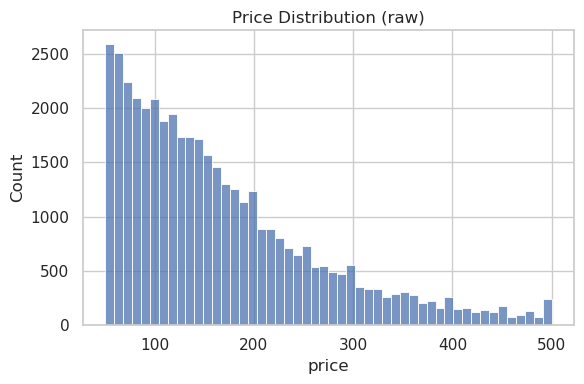

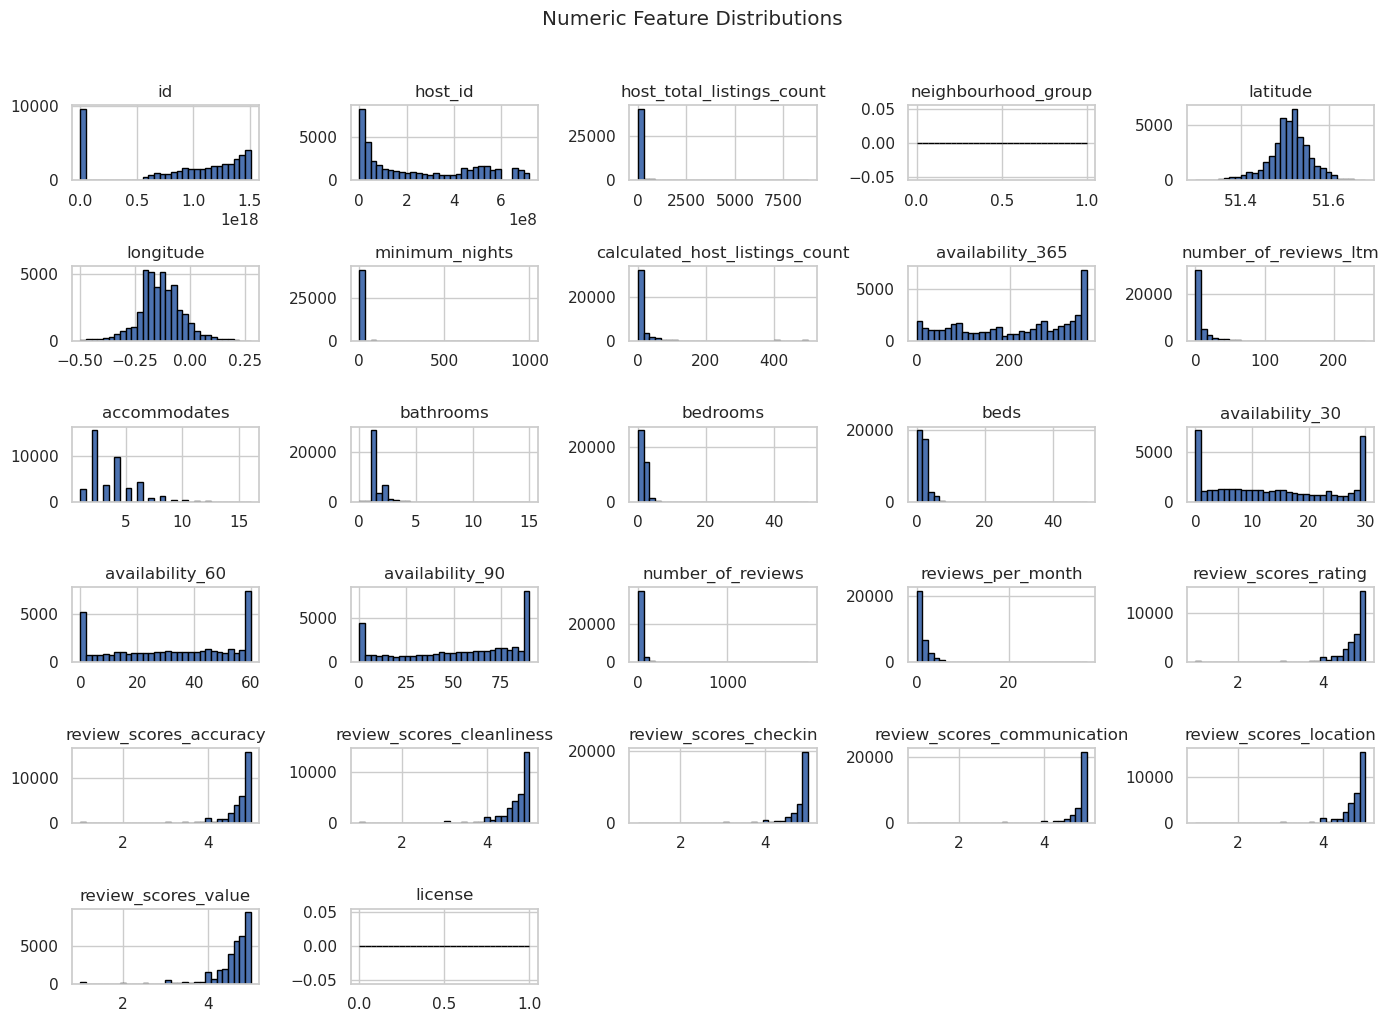

name: 41118 unique values
host_name: 9091 unique values
host_has_profile_pic: 2 unique values
host_identity_verified: 2 unique values
neighbourhood: 33 unique values
room_type: 4 unique values
amenities: 38642 unique values
last_review: 1660 unique values
Low-cardinality columns (e.g. room_type) will be one-hot encoded.
High-cardinality columns (e.g. name, host_name) will be dropped since they have too many unique values to encode in a useful way.


In [21]:
# Q2 Distribution

# Is price normally distributed? What is the median price?
print("Median price: $", train_df['price'].median())
print("Mean price:   $", round(train_df['price'].mean(), 2))

fig, axes = plt.subplots(figsize=(6, 4))
sns.histplot(train_df['price'], bins=50)
plt.title('Price Distribution (raw)')
plt.tight_layout()
plt.show()

# How are numeric features distributed?
numeric_cols = train_df.select_dtypes(include='number').columns.drop('price')
train_df[numeric_cols].hist(figsize=(14, 10), bins=30, edgecolor='black')
plt.suptitle('Numeric Feature Distributions', y=1.02)
plt.tight_layout()
plt.show()

# How many unique values does each non-numeric column have? How will we handle them?
cat_cols = train_df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"{col}: {train_df[col].nunique()} unique values")
    
print("Low-cardinality columns (e.g. room_type) will be one-hot encoded.")
print("High-cardinality columns (e.g. name, host_name) will be dropped since they have too many unique values to encode in a useful way.")

In [39]:
print("Q2 Distribution Answer:\n")
print("Price is not normally distributed; the raw plot is strongly right-skewed, with most listings under $200 and a long tail toward $500+.")
print(f"The median price is ${train_df['price'].median()} and mean is ${round(train_df['price'].mean(), 2)} (the gap confirms the skew).\n")
print("Most numeric features are also right-skewed, not normally distributed, as seen in the histogram grid.\n")
print("For categorical columns: name (41,118 unique) and host_name (9,091 unique) and amenities (38,642 unique) and last_review (1,660 unique) will be dropped.")
print("room_type (4 unique), host_has_profile_pic (2 unique), host_identity_verified (2 unique), and neighbourhood (33 unique) will be one-hot encoded.")

Q2 Distribution Answer:

Price is not normally distributed; the raw plot is strongly right-skewed, with most listings under $200 and a long tail toward $500+.
The median price is $141.0 and mean is $166.24 (the gap confirms the skew).

Most numeric features are also right-skewed, not normally distributed, as seen in the histogram grid.

For categorical columns: name (41,118 unique) and host_name (9,091 unique) and amenities (38,642 unique) and last_review (1,660 unique) will be dropped.
room_type (4 unique), host_has_profile_pic (2 unique), host_identity_verified (2 unique), and neighbourhood (33 unique) will be one-hot encoded.


# Data cleansing / Feature Engineering 

In [22]:
from sklearn.preprocessing import OneHotEncoder

# Drop useless/mostly-missing columns
cols_to_drop = ['name', 'host_name', 'amenities', 'last_review', 'neighbourhood_group', 'license']
train_df = train_df.drop(columns=cols_to_drop, errors='ignore')
test_df  = test_df.drop(columns=cols_to_drop, errors='ignore')

# Separate target variable
y = train_df['price']
X = train_df.drop(columns=['price'])

# Fill missing numeric values with median of each column 
X = X.fillna(X.median(numeric_only=True))

# Apply same medians from training to test 
test_df = test_df.fillna(X.median(numeric_only=True))  

# Fill any remaining missing values
X = X.fillna('missing')
test_df = test_df.fillna('missing')

# One-hot encode categorical columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

ohe_array      = ohe.fit_transform(X[cat_cols])        # fit on train
ohe_test_array = ohe.transform(test_df[cat_cols])      # apply to test

ohe_df = pd.DataFrame(ohe_array,columns=ohe.get_feature_names_out(cat_cols), index=X.index)
ohe_test_df = pd.DataFrame(ohe_test_array, columns=ohe.get_feature_names_out(cat_cols), index=test_df.index)

X = pd.concat([X.drop(columns=cat_cols), ohe_df], axis=1)
test_df = pd.concat([test_df.drop(columns=cat_cols), ohe_test_df], axis=1)

print("X shape:", X.shape)
print("Test shape:", test_df.shape)
print("Missing values in X:", X.isnull().sum().sum())

X shape: (42234, 68)
Test shape: (8199, 68)
Missing values in X: 0


# Model preparation 

In [23]:
# Align test to match train columns exactly
test_df = test_df.reindex(columns=X.columns, fill_value=0)

# Model Construction
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

# Split training data into train/validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {X_train.shape[0]} rows, validating on {X_val.shape[0]} rows.")

Training on 33787 rows, validating on 8447 rows.


# Model

In [24]:
# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_val)
lr_rmse = root_mean_squared_error(y_val, lr_preds)
print("Linear Regression RMSE:", round(lr_rmse, 2))

# Model 2: Decision Tree
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
dt_preds = dt.predict(X_val)
dt_rmse = root_mean_squared_error(y_val, dt_preds)
print("Decision Tree RMSE:", round(dt_rmse, 2))

# Use whichever model had lower RMSE for final predictions
best_model = dt if dt_rmse < lr_rmse else lr
print("\nBest model:", type(best_model).__name__)

Linear Regression RMSE: 97.97
Decision Tree RMSE: 67.38

Best model: DecisionTreeRegressor


In [25]:
# Tune Decision Tree to improve RMSE
from sklearn.ensemble import RandomForestRegressor

# Try different max_depths on Decision Tree
for depth in [6, 8, 10, 12, 15]:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    preds = dt.predict(X_val)
    rmse = root_mean_squared_error(y_val, preds)
    print(f"Decision Tree max_depth={depth} RMSE: {round(rmse, 2)}")

# Random Forest 
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_val)
rf_rmse = root_mean_squared_error(y_val, rf_preds)
print(f"\nRandom Forest RMSE: {round(rf_rmse, 2)}")

Decision Tree max_depth=6 RMSE: 69.1
Decision Tree max_depth=8 RMSE: 66.64
Decision Tree max_depth=10 RMSE: 67.38
Decision Tree max_depth=12 RMSE: 69.39
Decision Tree max_depth=15 RMSE: 72.68

Random Forest RMSE: 56.9


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Final Model: Train Random Forest on full training data and generate predictions
rf_final = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_final.fit(X, y)

predictions = rf_final.predict(test_df)

pd.DataFrame(predictions, columns=['price']).to_csv('A4_predictions_ayacheikh.csv', index=False)
print("Predictions saved!")
print("Number of predictions:", len(predictions))

# Use of LLMs 

- I used Claude to help me understand the spec requirements and split up it up into different tasks.
- I also used Claude for debugging issues and help with the setup (trouble mounting my drive, which I ended up removing)
- Some of my prompts to Claude:
  --> "Why I am getting a ModuleNotFoundError for seaborn and KeyErrors during data cleaning?"
  --> "Would tuning the Decision Trees across multiple max_depth values help improve RMSE?"
  --> "Explain sklearn's OneHotEncoder in detail. Show how it's different from pd.get_dummies."

- I found it particularly useful for debugging environment-specific errors quickly and for explaining structuring the notebook structure.
- I learned that LLMs are most useful as a debugging and structuring tool rather than replacing understanding.